In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Revenue
df_revenue_by_month = pd.read_csv("data-analysis/revenue-by-month.csv")
df_revenue_by_category = pd.read_csv("data-analysis/revenue-by-category.csv")
df_revenue_by_customer_segment = pd.read_csv("data-analysis/revenue-by-customer-segment.csv")
df_revenue_per_state = pd.read_csv("data-analysis/revenue-per-state.csv")
#AOV
df_aov_by_category = pd.read_csv("data-analysis/aov-by-category.csv")
df_aov_by_customer_segment = pd.read_csv("data-analysis/aov-by-customer-segment.csv")
df_aov_by_month = pd.read_csv("data-analysis/aov-by-month.csv")

## Revenue by month

In [3]:
df_revenue_by_month.tail()

,month,revenue,quatily_order,mom
19,2018-05-01 00:00:00+07,1145748.63,6833,-0.91
20,2018-06-01 00:00:00+07,1020494.29,6145,-10.93
21,2018-07-01 00:00:00+07,1039880.16,6233,1.90
22,2018-08-01 00:00:00+07,996896.15,6421,-4.13
23,2018-09-01 00:00:00+07,166.46,1,-99.98


In [4]:
df_revenue_by_month['month'] = pd.to_datetime(df_revenue_by_month['month'])

In [5]:
df_revenue_by_month.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype                    
---  ------         --------------  -----                    
 0   month          24 non-null     datetime64[ns, UTC+07:00]
 1   revenue        24 non-null     float64                  
 2   quatily_order  24 non-null     int64                    
 3   mom            23 non-null     float64                  
dtypes: datetime64[ns, UTC+07:00](1), float64(2), int64(1)
memory usage: 900.0 bytes


In [6]:
df_revenue_by_month = df_revenue_by_month.sort_values('month')
df_revenue_by_month = df_revenue_by_month.set_index('month')

<Axes: xlabel='month'>

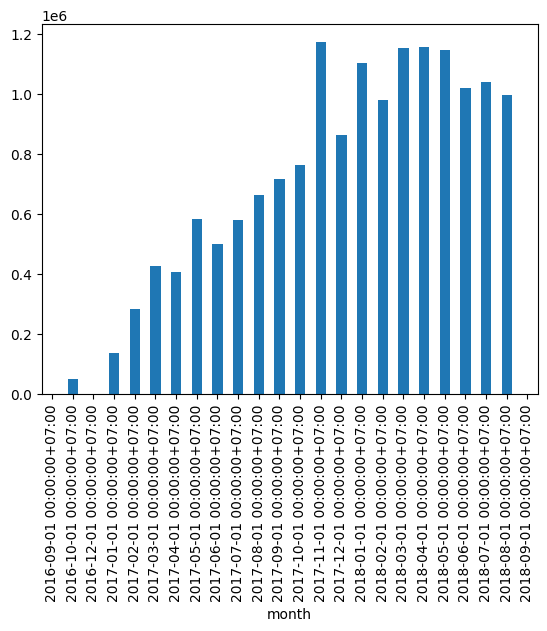

In [7]:
df_revenue_by_month['revenue'].plot(kind='bar')

Doanh thu từ 2016 đến 2018 có sự tăng trưởng 

In [8]:
df_revenue_by_month.columns

Index(['revenue', 'quatily_order', 'mom'], dtype='object')

<Axes: >

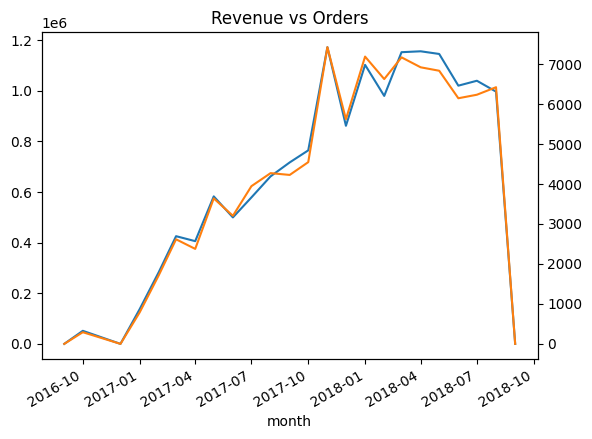

In [9]:
ax = df_revenue_by_month['revenue'].plot(title='Revenue vs Orders');
df_revenue_by_month['quatily_order'].plot(secondary_y=True, ax=ax)

## Revenue by category

In [10]:
df_revenue_by_category.head()

,category,revenue_item,revenue_percent
0,beleza_saude,1437665.78,9.14
1,relogios_presentes,1298292.47,8.25
2,cama_mesa_banho,1240386.13,7.88
3,esporte_lazer,1147244.63,7.29
4,informatica_acessorios,1050941.58,6.68


In [11]:
df_revenue_by_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   category         74 non-null     object 
 1   revenue_item     74 non-null     float64
 2   revenue_percent  74 non-null     float64
dtypes: float64(2), object(1)
memory usage: 1.9+ KB


<Figure size 1200x600 with 0 Axes>

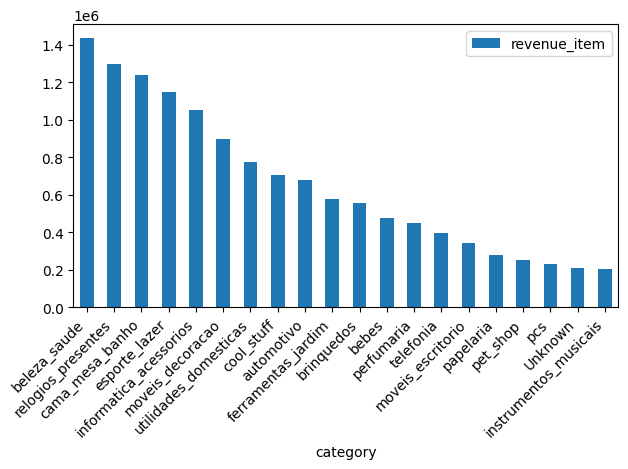

In [12]:
top_df = df_revenue_by_category.sort_values(by='revenue_item', ascending=False).head(20)
plt.figure(figsize=(12, 6))
top_df.plot.bar(x='category', y='revenue_item')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [13]:
df_revenue_by_customer_segment.head()

,segment,customer_count,total_revenue,revenue_percent
0,One-time,92101,14848602.89,94.34
1,Repeat,2840,853088.12,5.42
2,High-value,48,37446.00,0.24


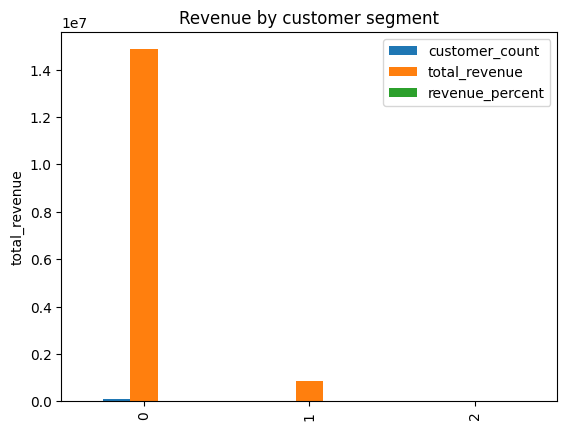

In [14]:
df_revenue_by_customer_segment.plot(kind='bar', ylabel='total_revenue', title='Revenue by customer segment');

In [15]:
df_revenue_per_state.head()

,seller_state,total_orders,total_revenue,avg_order_value,revenue_percent
0,SP,69854,10163091.37,145.49,64.59
1,PR,7647,1453098.55,190.02,9.23
2,MG,7880,1213270.24,153.97,7.71
3,RJ,4330,930917.92,214.99,5.92
4,SC,3649,729704.76,199.97,4.64


<Axes: xlabel='seller_state'>

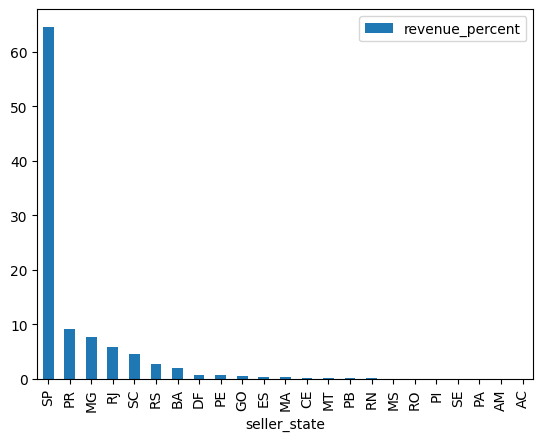

In [16]:
df_revenue_per_state.plot.bar(x='seller_state', y='revenue_percent')

## AOV by month

In [17]:
df_aov_by_month.head()

,month,revenue,orders,aov,aov_growth
0,2016-09-01 00:00:00+07,136.23,1,136.23,NaN
1,2016-10-01 00:00:00+07,51657.53,293,176.31,29.42
2,2016-12-01 00:00:00+07,19.62,1,19.62,-88.87
3,2017-01-01 00:00:00+07,137006.76,787,174.09,787.31
4,2017-02-01 00:00:00+07,283621.94,1718,165.09,-5.17


In [18]:
df_aov_by_month[['orders', 'aov']].corr()

,orders,aov
orders,1.000000,0.276758
aov,0.276758,1.000000


<Axes: xlabel='orders', ylabel='aov'>

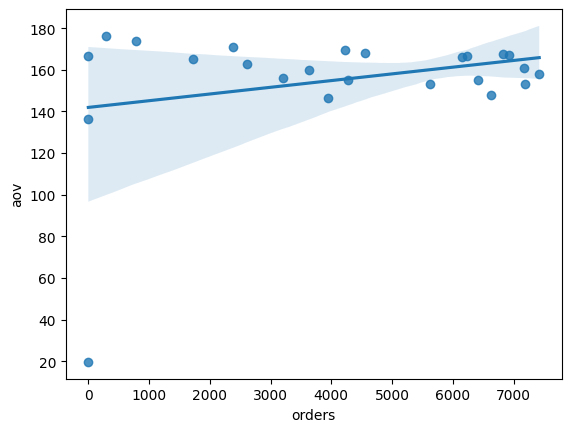

In [19]:
sns.regplot(data=df_aov_by_month, x='orders', y='aov')

In [20]:
df_aov_by_month = df_aov_by_month.sort_values('month')
df_aov_by_month = df_aov_by_month.set_index('month')

(array([-5.,  0.,  5., 10., 15., 20., 25.]),
 [Text(-5.0, 0, '2018-05-01 00:00:00+07'),
  Text(0.0, 0, '2016-09-01 00:00:00+07'),
  Text(5.0, 0, '2017-03-01 00:00:00+07'),
  Text(10.0, 0, '2017-08-01 00:00:00+07'),
  Text(15.0, 0, '2018-01-01 00:00:00+07'),
  Text(20.0, 0, '2018-06-01 00:00:00+07'),
  Text(25.0, 0, '')])

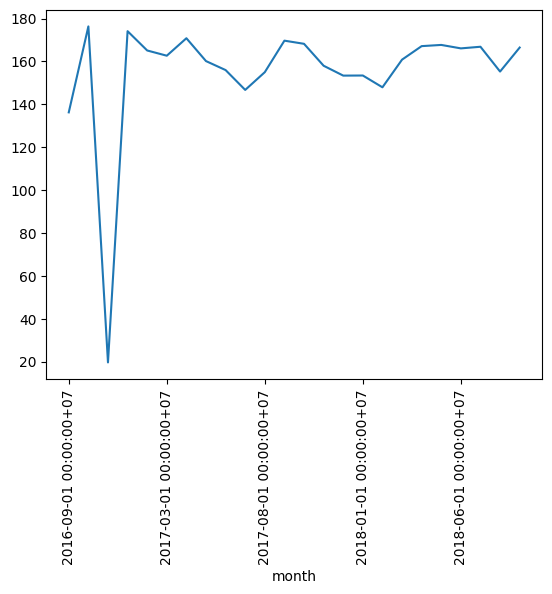

In [21]:
df_aov_by_month['aov'].plot()
plt.xticks(rotation=90)

In [22]:
customer_type_over_time = pd.read_csv('data-analysis/customer-type-over-time.csv')
customer_type_over_time.head()

,month,total_customers,new_customers,repeat_customers,repeat_rate
0,2016-09-01 00:00:00+07,2,2,0,0.0000
1,2016-10-01 00:00:00+07,290,290,3,0.0103
2,2016-12-01 00:00:00+07,1,1,0,0.0000
3,2017-01-01 00:00:00+07,753,752,26,0.0345
4,2017-02-01 00:00:00+07,1693,1690,25,0.0148


In [23]:
customer_type_over_time = customer_type_over_time.sort_values('month')
customer_type_over_time = customer_type_over_time.set_index('month')

<Axes: xlabel='month'>

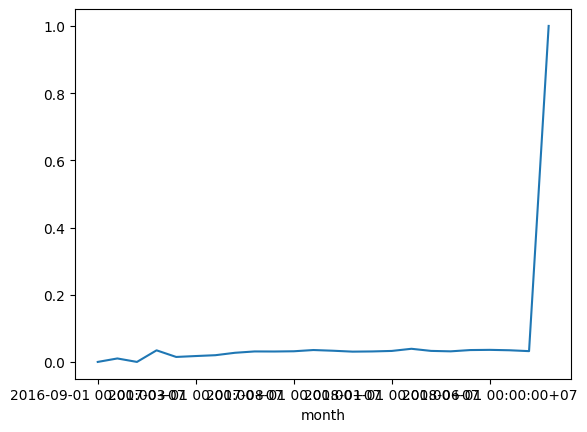

In [24]:
customer_type_over_time['repeat_rate'].plot()